
## Reproducibility Notes

**Random Seed**: Set to `42` for consistent results across runs

**Simulation Parameters**: 
- **Days**: 365 (1 year)
- **Players**: ~1,580 total
  - 1,500 procedural players across 5 core strategies (~300 each via random sampling)
  - 60 adaptive players (3 sub-types × 20: Expert, Scrapper, Desperate)
  - 20 benchmark players + 1 perfect player

**Daily Difficulty** (drawn randomly each day, visible to all strategies before they act):
| Tier   | Clue Value | Probability | Accuracy modifier |
|--------|-----------|-------------|-------------------|
| Low    | 100 pts   | 35%         | +5%               |
| Medium | 200 pts   | 40%         | ±0%               |
| High   | 300 pts   | 25%         | −20%              |

**Core Strategies**: Troll (jinx), Rester (rest), Thief (steal), Random (mixed), Passive (no powerups), Adaptive (near-optimal decision tree)

These choices ensure:
1. **Consistent results** — Same seed produces identical outcomes
2. **Narrow confidence intervals** — Large sample size reduces statistical variance
3. **Reliable strategy comparison** — Clear winners and losers with minimal overlap


# Powerup Simulation Analysis

This notebook runs the simulation logic defined in `simulate_powerups.py` and visualizes the results with 95% Confidence Intervals.

## Setup

In [1]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Add current directory to path to import script
sys.path.append(os.getcwd())

from simulate_powerups import (
    run_simulation,
    ProceduralStrategy,
    BenchmarkStrategy,
    AdaptiveStrategy,
    DIFFICULTY_WEIGHTS,
    DIFFICULTY_VALUES,
    SIMULATION_DAYS,
)

# Set Plot Style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
def get_rank_palette(df, cat_col, val_col="Score Ratio"):
    """
    Returns a palette dictionary where:
    1st (highest mean, non-Benchmark) -> Gold
    2nd -> Silver
    3rd -> Bronze
    Others -> Muted Blue
    Benchmark -> Muted Gray (reference, not ranked)
    """
    # Rank only real strategies; Benchmark is a reference tool, not a competitor
    means = (
        df[df[cat_col] != "Benchmark"]
        .groupby(cat_col)[val_col]
        .mean()
        .sort_values(ascending=False)
    )
    ranks = means.index.tolist()

    palette = {}
    medal_colors = {0: "#FFD700", 1: "#C0C0C0", 2: "#CD7F32"}
    benchmark_color = "#A0A0A0"  # Muted gray — comparison reference only
    default_color = "#5975A4"  # Muted Blue

    for i, cat in enumerate(ranks):
        palette[cat] = medal_colors.get(i, default_color)

    # Always override Benchmark regardless of its value ranking
    if "Benchmark" in df[cat_col].values:
        palette["Benchmark"] = benchmark_color

    return palette


def add_bar_labels(ax, fmt="%.3f"):
    """Adds labels inside the bars in a bar plot."""
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, label_type="edge", padding=-50)

## Simulate

In [3]:
# Run the Simulation
import random
import numpy as np
from tqdm.auto import tqdm

# Set Random Seed for Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Running Simulation... (This may take a moment)")

with tqdm(total=SIMULATION_DAYS, desc="Simulating days", unit="day") as pbar:
    players, strategies, daily_records = run_simulation(
        return_data=True,
        seed=SEED,
        on_day_complete=pbar.update,
    )

print(
    f"Simulation Complete. Processed {len(players)} players, {len(daily_records):,} daily observations."
)

c:\Users\Blake\anaconda3\envs\jbot\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running Simulation... (This may take a moment)


Simulating days:   0%|          | 1/365 [00:00<01:03,  5.76day/s]

Starting simulation for 365 days...


Simulating days: 100%|██████████| 365/365 [01:10<00:00,  5.18day/s]

Simulation Complete. Processed 1581 players, 192,882 daily observations.


In [4]:
# Build per-day DataFrame for difficulty analysis
daily_df = pd.DataFrame(daily_records)

# Exclude Benchmark from difficulty charts — it doesn't change behaviour by design
daily_df = daily_df[daily_df["core_strategy"] != "Benchmark"]

# Map None powerup_type to "none" for cleaner grouping
daily_df["powerup_type"] = daily_df["powerup_type"].fillna("none")

# Ordered difficulty axis
daily_df["difficulty"] = pd.Categorical(
    daily_df["difficulty"], categories=["Low", "Medium", "High"], ordered=True
)

In [5]:
# Build DataFrame
data = []

# Calculate Benchmark Mean for Ratio
benchmark_scores = [
    p.score for pid, p in players.items() if strategies[pid].name == "Benchmark"
]
benchmark_mean = (
    sum(benchmark_scores) / len(benchmark_scores) if benchmark_scores else 1
)

for pid, p in players.items():
    strat = strategies[pid]

    row = {
        "Name": p.name,
        "Score": p.score,
        "Score Ratio": p.score / benchmark_mean,
        "Streak": p.answer_streak,
        "Strategy Type": strat.name,
    }

    # Extract Dimensions
    if isinstance(strat, ProceduralStrategy):
        row["Core Strategy"] = strat.core_strategy
        row["Speed"] = strat.speed
        row["Correctness"] = strat.correctness
        row["Aggression"] = strat.aggression
    elif isinstance(strat, BenchmarkStrategy):
        row["Core Strategy"] = "Benchmark"
        row["Speed"] = "N/A"
        row["Correctness"] = "N/A"
        row["Aggression"] = "N/A"
    else:
        # Fallback
        row["Core Strategy"] = strat.name
        row["Speed"] = "N/A"
        row["Correctness"] = "N/A"
        row["Aggression"] = "N/A"

    data.append(row)

df = pd.DataFrame(data)

# Benchmark first (it's a reference), then strategies ranked highest → lowest Score Ratio
_non_benchmark_order = (
    df[df["Core Strategy"] != "Benchmark"]
    .groupby("Core Strategy")["Score Ratio"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)
ranked_strategy_order = ["Benchmark"] + _non_benchmark_order

df.head()

,Name,Score,Score Ratio,Streak,Strategy Type,Core Strategy,Speed,Correctness,Aggression
0,Benchmark_1,80965,1.021307,338,Benchmark,Benchmark,N/A,N/A,N/A
1,Benchmark_2,77960,0.983402,325,Benchmark,Benchmark,N/A,N/A,N/A
2,Benchmark_3,80365,1.013739,332,Benchmark,Benchmark,N/A,N/A,N/A
3,Benchmark_4,78590,0.991349,329,Benchmark,Benchmark,N/A,N/A,N/A
4,Benchmark_5,80310,1.013045,333,Benchmark,Benchmark,N/A,N/A,N/A


## Results by dimension

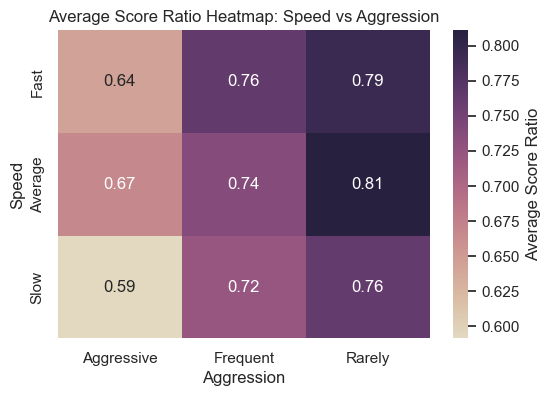

In [6]:
# Heatmap: Speed vs Aggression (Average Score Ratio)
# Filter for procedural only
proc_df = df[df["Speed"] != "N/A"]

heatmap_data_agg = proc_df.pivot_table(
    index="Speed", columns="Aggression", values="Score Ratio", aggfunc="mean"
)

# Reorder indices for better readability
speed_order = ["Fast", "Average", "Slow"]
agg_order = ["Aggressive", "Frequent", "Rarely"]
# Filter to existing
speed_order_agg = [s for s in speed_order if s in heatmap_data_agg.index]
agg_order_agg = [a for a in agg_order if a in heatmap_data_agg.columns]

heatmap_data_agg = heatmap_data_agg.reindex(
    index=speed_order_agg, columns=agg_order_agg
)

plt.figure(figsize=(6, 4))
sns.heatmap(
    heatmap_data_agg,
    annot=True,
    fmt=".2f",
    # https://seaborn.pydata.org/tutorial/color_palettes.html
    cmap=sns.color_palette("ch:s=-.2,r=.6", as_cmap=True),
    cbar_kws={"label": "Average Score Ratio"},
)
plt.title("Average Score Ratio Heatmap: Speed vs Aggression")
plt.show()

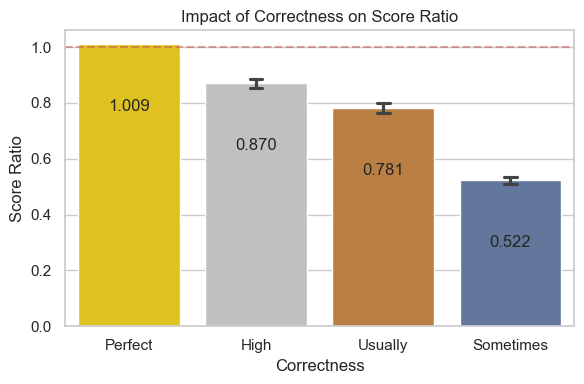

In [7]:
# Correctness Analysis — Speed and Aggression are covered by the heatmap above
dim_df = df[df["Speed"] != "N/A"]

acc_order = ["Perfect", "High", "Usually", "Sometimes"]
acc_pal = get_rank_palette(dim_df, "Correctness", "Score Ratio")

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=dim_df,
    x="Correctness",
    y="Score Ratio",
    order=acc_order,
    errorbar=("ci", 95),
    capsize=0.1,
    hue="Correctness",
    palette=acc_pal,
    legend=False,
)
ax.axhline(1.0, color="r", linestyle="--", alpha=0.5, label="Benchmark")
add_bar_labels(ax, fmt="%.3f")
plt.title("Impact of Correctness on Score Ratio")
plt.tight_layout()
plt.show()

## Results by strategy

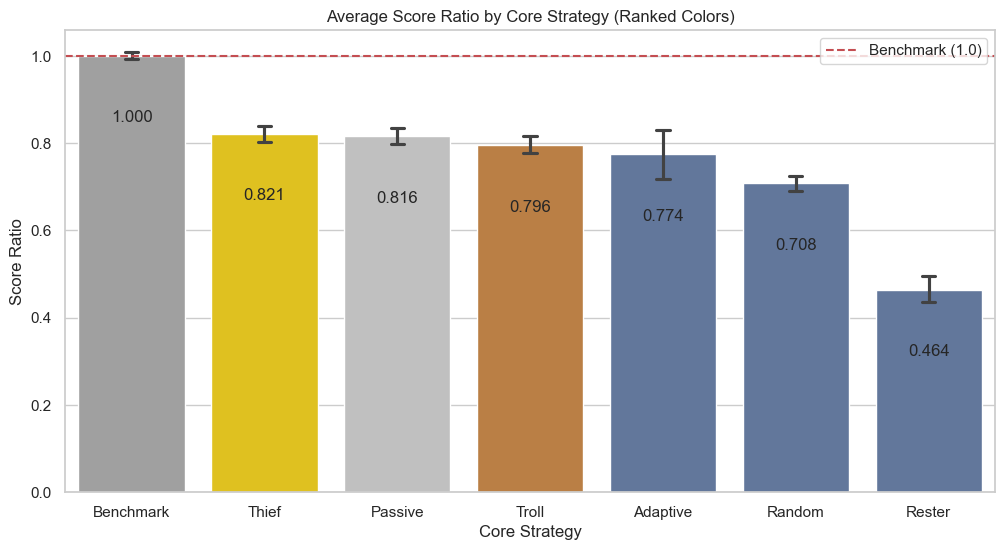

In [8]:
# Core Strategy Performance
plt.figure(figsize=(12, 6))

# Define palette based on rank (Gold, Silver, Bronze...)
palette = get_rank_palette(df, "Core Strategy", "Score Ratio")

# Using Score Ratio with modern seaborn API
ax = sns.barplot(
    data=df,
    x="Core Strategy",
    y="Score Ratio",
    order=ranked_strategy_order,
    errorbar=("ci", 95),
    capsize=0.1,
    hue="Core Strategy",
    palette=palette,
    legend=False,
)

# Add Labels
add_bar_labels(ax, fmt="%.3f")

plt.title("Average Score Ratio by Core Strategy (Ranked Colors)")
plt.axhline(1.0, color="r", linestyle="--", label="Benchmark (1.0)")
plt.legend()
plt.show()

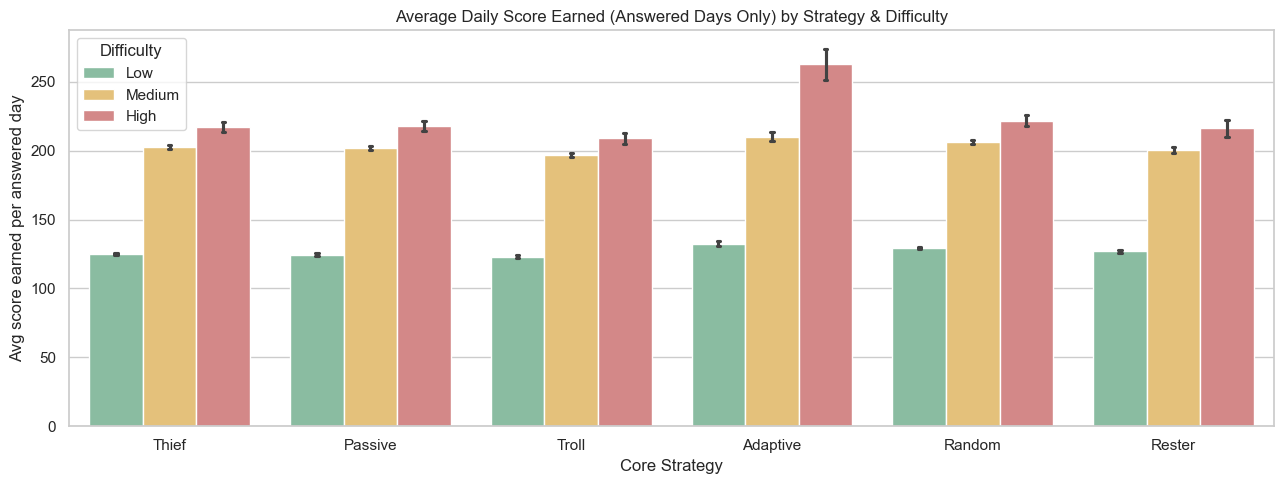

In [9]:
# Average daily score earned (excluding rest days) by difficulty per strategy.
# Shows which strategies extract the most value out of each tier when they do guess.
answered_df = daily_df[~daily_df["rested"]].copy()

plt.figure(figsize=(13, 5))
ax = sns.barplot(
    data=answered_df,
    x="core_strategy",
    y="score_earned",
    hue="difficulty",
    hue_order=["Low", "Medium", "High"],
    palette={"Low": "#82C4A0", "Medium": "#F5C76A", "High": "#E07B7B"},
    order=[
        s for s in ranked_strategy_order if s in answered_df["core_strategy"].unique()
    ],
    errorbar=("ci", 95),
    capsize=0.05,
)
plt.title("Average Daily Score Earned (Answered Days Only) by Strategy & Difficulty")
plt.xlabel("Core Strategy")
plt.ylabel("Avg score earned per answered day")
plt.legend(title="Difficulty")
plt.tight_layout()
plt.show()

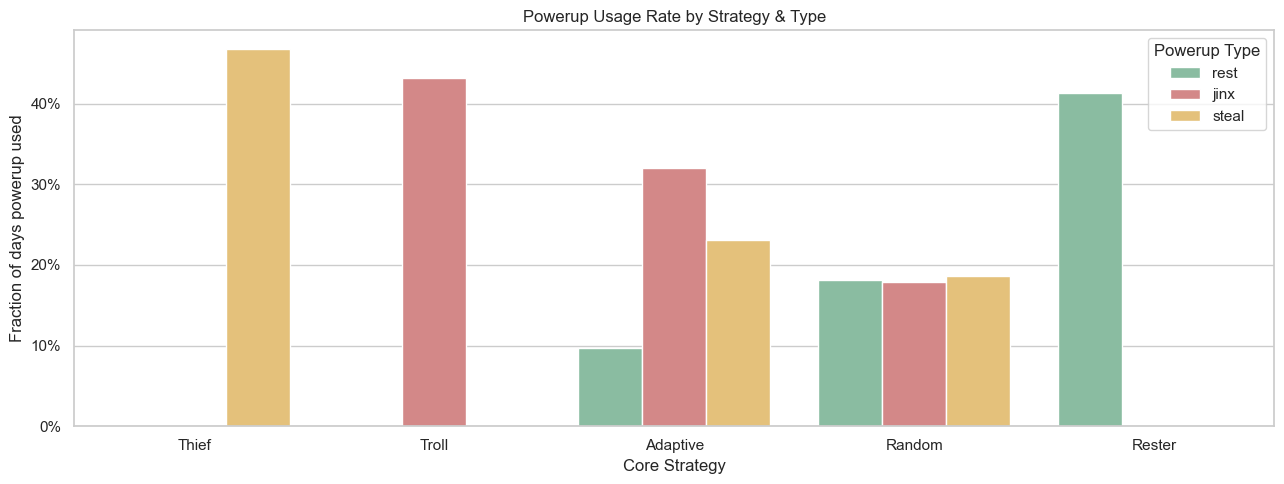

In [10]:
# Powerup Usage Rate by Strategy & Type
# Shows the fraction of (sampled) days each strategy fires each powerup
powerup_rate = (
    daily_df[daily_df["powerup_type"] != "none"]
    .groupby(["core_strategy", "powerup_type"])
    .size()
    .reset_index(name="count")
)
total_per_strat = daily_df.groupby("core_strategy").size().reset_index(name="total")
powerup_rate = powerup_rate.merge(total_per_strat, on="core_strategy")
powerup_rate["usage_rate"] = powerup_rate["count"] / powerup_rate["total"]

strat_order_filtered = [
    s for s in ranked_strategy_order if s in powerup_rate["core_strategy"].unique()
]

plt.figure(figsize=(13, 5))
ax = sns.barplot(
    data=powerup_rate,
    x="core_strategy",
    y="usage_rate",
    hue="powerup_type",
    hue_order=["rest", "jinx", "steal"],
    palette={"rest": "#82C4A0", "jinx": "#E07B7B", "steal": "#F5C76A"},
    order=strat_order_filtered,
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.title("Powerup Usage Rate by Strategy & Type")
plt.xlabel("Core Strategy")
plt.ylabel("Fraction of days powerup used")
plt.legend(title="Powerup Type")
plt.tight_layout()
plt.show()

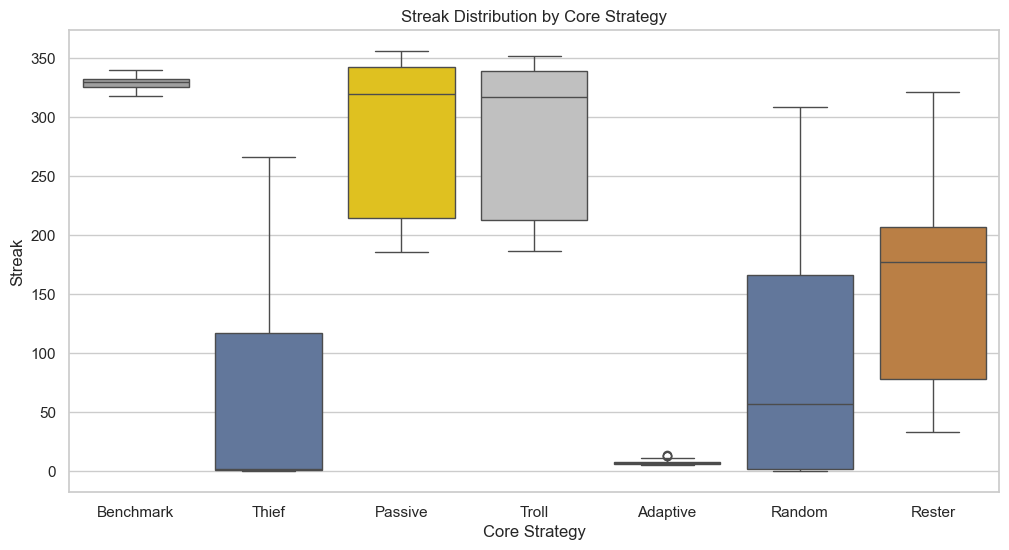

In [11]:
# Streak Distribution by Core Strategy (Benchmark first, then ranked)
plt.figure(figsize=(12, 6))
streak_pal = get_rank_palette(df, "Core Strategy", "Streak")
sns.boxplot(
    data=df,
    x="Core Strategy",
    y="Streak",
    order=ranked_strategy_order,
    hue="Core Strategy",
    palette=streak_pal,
    legend=False,
)
plt.title("Streak Distribution by Core Strategy")
plt.show()

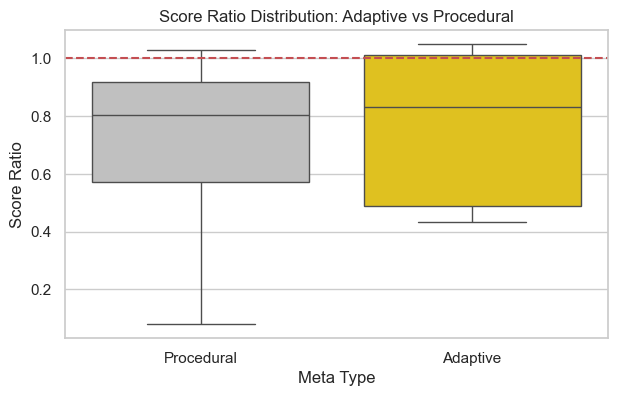

In [12]:
# Adaptive vs Procedural
# Is Adaptive better than the sum of its parts?
plt.figure(figsize=(7, 4))

comparison_df = df[
    df["Strategy Type"].str.contains("Adaptive|Passive|Thief|Troll|Rester|Random")
].copy()
comparison_df["Meta Type"] = comparison_df["Strategy Type"].apply(
    lambda x: "Adaptive" if "Adaptive" in x else "Procedural"
)

# Custom palette for just two items doesn't need bronze, but consistent with rank
meta_pal = get_rank_palette(comparison_df, "Meta Type", "Score Ratio")

sns.boxplot(
    data=comparison_df,
    x="Meta Type",
    y="Score Ratio",
    hue="Meta Type",
    palette=meta_pal,
    legend=False,
)
plt.title("Score Ratio Distribution: Adaptive vs Procedural")
plt.axhline(1.0, color="r", linestyle="--", label="Benchmark")
plt.show()

### Top Performers

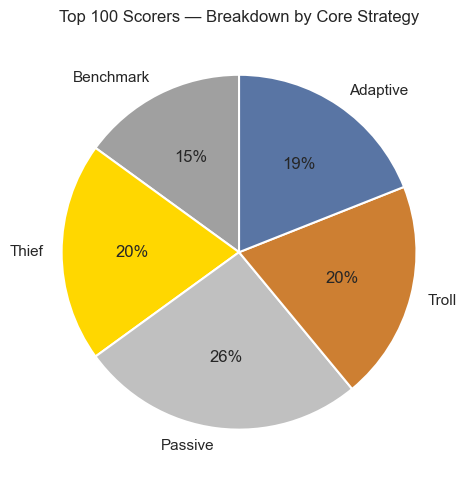

In [13]:
# Pie chart: which strategies dominate the top 100 scorers?
top100 = df.nlargest(100, "Score")
top100_counts = top100["Core Strategy"].value_counts()

# Preserve ranked order (Benchmark first) for consistent slice ordering
pie_order = [s for s in ranked_strategy_order if s in top100_counts.index]
counts = top100_counts.reindex(pie_order)

pie_pal = get_rank_palette(df, "Core Strategy", "Score Ratio")
colors = [pie_pal[s] for s in pie_order]

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    counts,
    labels=pie_order,
    colors=colors,
    autopct="%1.0f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
ax.set_title("Top 100 Scorers — Breakdown by Core Strategy")
plt.tight_layout()
plt.show()

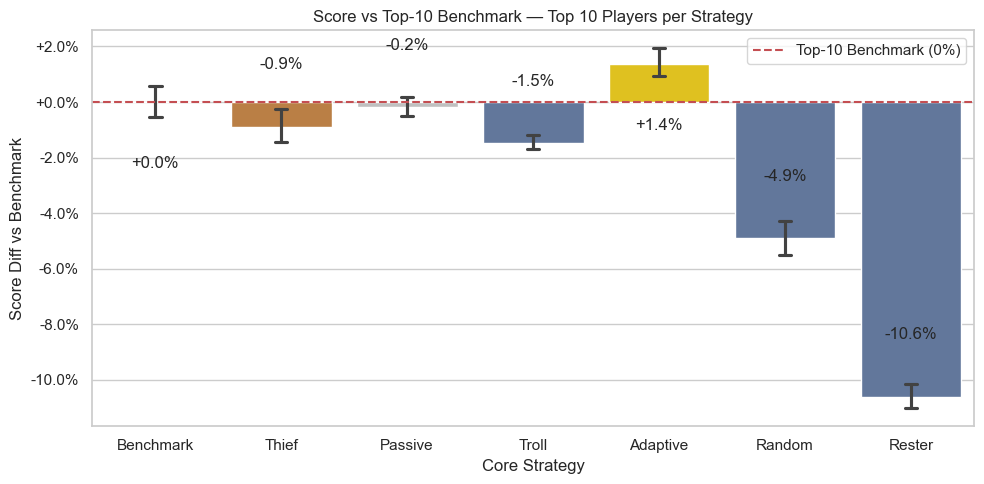

In [14]:
# Top 10 Score Ratio by Core Strategy — shows the ceiling of each strategy
top10_per_strat = (
    df.sort_values("Score Ratio", ascending=False)
    .groupby("Core Strategy", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

# Recompute Score Ratio relative to the top-10 Benchmark players' average score,
# then express as a diff (+/-) against that baseline
top10_benchmark_mean = top10_per_strat[top10_per_strat["Core Strategy"] == "Benchmark"][
    "Score"
].mean()
top10_per_strat = top10_per_strat.copy()
top10_per_strat["Score Diff"] = (top10_per_strat["Score"] / top10_benchmark_mean) - 1.0

# Colors ranked by the top-10 subset; order stays consistent with all other charts
top10_palette = get_rank_palette(top10_per_strat, "Core Strategy", "Score Diff")

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=top10_per_strat,
    x="Core Strategy",
    y="Score Diff",
    order=ranked_strategy_order,
    errorbar=("ci", 95),
    capsize=0.1,
    hue="Core Strategy",
    palette=top10_palette,
    legend=False,
)
# bar_label fmt uses C printf syntax — use explicit labels for Python-style formatting
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v:+.1%}" for v in container.datavalues],
        label_type="edge",
        padding=-50,
    )
plt.title("Score vs Top-10 Benchmark — Top 10 Players per Strategy")
plt.axhline(0, color="r", linestyle="--", label="Top-10 Benchmark (0%)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.1%}"))
plt.ylabel("Score Diff vs Benchmark")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# Top 1 per strategy — single compact table
pd.set_option("display.float_format", "{:.3f}".format)

top1_rows = []
for strategy in ranked_strategy_order:
    strat_df = df[df["Core Strategy"] == strategy]
    if strat_df.empty:
        continue
    top1_rows.append(strat_df.nlargest(1, "Score").iloc[0])

top1_df = pd.DataFrame(top1_rows)[
    [
        "Core Strategy",
        "Name",
        "Score",
        "Score Ratio",
        "Streak",
        "Speed",
        "Correctness",
        "Aggression",
    ]
].reset_index(drop=True)

print("\nTop 1 Player per Core Strategy:\n")
print(top1_df.to_string(index=False))

pd.reset_option("display.float_format")


Top 1 Player per Core Strategy:

Core Strategy              Name  Score  Score Ratio  Streak   Speed Correctness Aggression
    Benchmark      Benchmark_18  81905        1.033     338     N/A         N/A        N/A
        Thief     Thief_FHR_612  81610        1.029     215    Fast        High     Rarely
      Passive   Passive_FHR_766  81515        1.028     356    Fast        High     Rarely
        Troll     Troll_FHF_282  80110        1.011     352    Fast        High   Frequent
     Adaptive Adaptive_Expert_9  83101        1.048       8    Fast        High   Frequent
       Random    Random_FHR_520  77936        0.983     301    Fast        High     Rarely
       Rester    Rester_AHR_856  72958        0.920     321 Average        High     Rarely


In [16]:
# Top Performers Analysis — top 15 individual players across all strategies
top_performers = df.sort_values("Score", ascending=False).head(15)

print("Top 15 Performing Players:")
display_cols = [
    "Name",
    "Score",
    "Score Ratio",
    "Streak",
    "Core Strategy",
    "Speed",
    "Correctness",
    "Aggression",
]
print(top_performers[display_cols].to_string(index=False))

Top 15 Performing Players:
              Name  Score  Score Ratio  Streak Core Strategy Speed Correctness Aggression
 Adaptive_Expert_9  83101     1.048251       8      Adaptive  Fast        High   Frequent
 Adaptive_Expert_3  81936     1.033556       7      Adaptive  Fast        High   Frequent
      Benchmark_18  81905     1.033165     338     Benchmark   N/A         N/A        N/A
Adaptive_Expert_19  81858     1.032572       9      Adaptive  Fast        High   Frequent
      Benchmark_19  81785     1.031651     340     Benchmark   N/A         N/A        N/A
Adaptive_Expert_10  81710     1.030705       9      Adaptive  Fast        High   Frequent
 Adaptive_Expert_1  81656     1.030024      11      Adaptive  Fast        High   Frequent
     Thief_FHR_612  81610     1.029443     215         Thief  Fast        High     Rarely
   Passive_FHR_766  81515     1.028245     356       Passive  Fast        High     Rarely
Adaptive_Expert_18  81485     1.027867      10      Adaptive  Fast       

## Performance Tiers

Players are split into Bottom / Middle / Top tertiles by final score, so we can see whether patterns observed in the full population look different for players who ended up struggling vs. thriving.

In [17]:
# --- Tertile Setup ---
# Split all players into three equal-sized groups by final Score.
# We intentionally exclude Benchmark from tertile assignment so we compare
# the "real" strategies on equal footing (Benchmark is a reference, not a
# competitor).

proc_non_bench = df[df["Core Strategy"] != "Benchmark"].copy()

proc_non_bench["Tier"] = pd.qcut(
    proc_non_bench["Score"],
    q=3,
    labels=["Bottom", "Middle", "Top"],
)

TERTILE_ORDER = ["Top", "Middle", "Bottom"]
TERTILE_COLORS = {"Top": "#FFD700", "Middle": "#5975A4", "Bottom": "#E07B7B"}

# Procedural-only subset (has Correctness / Speed / Aggression columns)
proc_tier = proc_non_bench[proc_non_bench["Speed"] != "N/A"].copy()

print(f"Tier counts (all strategies excl. Benchmark):")
print(proc_non_bench["Tier"].value_counts().sort_index())

print(f"Tier counts (procedural-only subset):")
print(proc_tier["Tier"].value_counts().sort_index())

Tier counts (all strategies excl. Benchmark):
Tier
Bottom    522
Middle    519
Top       520
Name: count, dtype: int64
Tier counts (procedural-only subset):
Tier
Bottom    522
Middle    519
Top       520
Name: count, dtype: int64


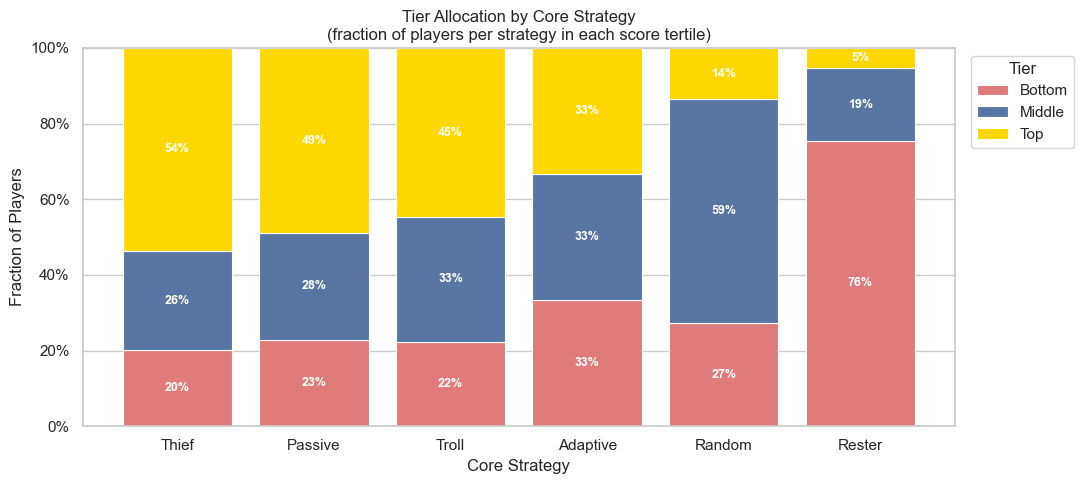

In [18]:
# Strategy Tier Allocation — stacked bar
# For each core strategy, what fraction of its players land in each tier?
# High Top share → reliable top-tier factory. High Bottom share → consistently bad.

strat_tier = (
    proc_non_bench.groupby(["Core Strategy", "Tier"], observed=True)
    .size()
    .reset_index(name="count")
)
strat_total = proc_non_bench.groupby("Core Strategy").size().reset_index(name="total")
strat_tier = strat_tier.merge(strat_total, on="Core Strategy")
strat_tier["fraction"] = strat_tier["count"] / strat_tier["total"]

# Pivot for stacking
tier_pivot = strat_tier.pivot_table(
    index="Core Strategy",
    columns="Tier",
    values="fraction",
    fill_value=0,
    observed=True,
).reindex(columns=["Bottom", "Middle", "Top"])

# Sort strategies by Top-tier fraction descending (most dominant at top)
tier_pivot = tier_pivot.reindex(tier_pivot["Top"].sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(11, 5))
bottom = pd.Series([0.0] * len(tier_pivot), index=tier_pivot.index)
for tier in ["Bottom", "Middle", "Top"]:
    vals = tier_pivot[tier]
    bars = ax.bar(
        tier_pivot.index,
        vals,
        bottom=bottom,
        color=TERTILE_COLORS[tier],
        label=tier,
        edgecolor="white",
        linewidth=0.8,
    )
    for bar, val in zip(bars, vals):
        if val > 0.05:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.0%}",
                ha="center",
                va="center",
                fontsize=9,
                color="white",
                fontweight="bold",
            )
    bottom += vals

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_ylim(0, 1)
ax.set_title(
    "Tier Allocation by Core Strategy\n(fraction of players per strategy in each score tertile)"
)
ax.set_xlabel("Core Strategy")
ax.set_ylabel("Fraction of Players")
ax.legend(title="Tier", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Breakdown by Dimension

Two complementary views:
- **Causal view** — for each dimension value, what tier do those players land in?  
- **Profile view** — for each tier, what's the dimension mix?

Together they answer both "what leads to a bad outcome?" and "what kinds of players make up the bottom tier?"

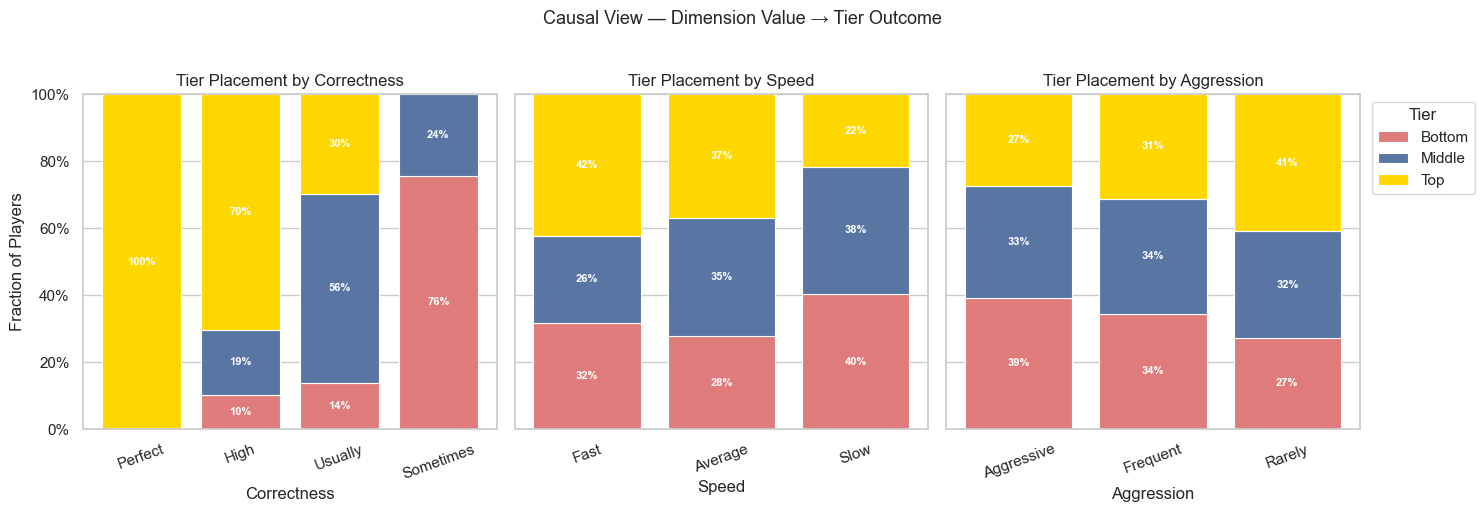

In [19]:
# Causal view — given a dimension value, where do those players land?
# Each bar group is a dimension VALUE; the stacked bars show tier fractions.
# Read this as: "Of all Fast players, X% ended up in the Top tier."

DIMS = {
    "Correctness": ["Perfect", "High", "Usually", "Sometimes"],
    "Speed": ["Fast", "Average", "Slow"],
    "Aggression": ["Aggressive", "Frequent", "Rarely"],
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (dim, order) in zip(axes, DIMS.items()):
    pivot = (
        proc_tier.groupby([dim, "Tier"], observed=True).size().reset_index(name="count")
    )
    totals = proc_tier.groupby(dim).size().reset_index(name="total")
    pivot = pivot.merge(totals, on=dim)
    pivot["fraction"] = pivot["count"] / pivot["total"]
    pivot = pivot.pivot_table(
        index=dim, columns="Tier", values="fraction", fill_value=0, observed=True
    ).reindex(index=order, columns=["Bottom", "Middle", "Top"])

    bottom_arr = pd.Series([0.0] * len(pivot), index=pivot.index)
    for tier in ["Bottom", "Middle", "Top"]:
        vals = pivot[tier]
        bars = ax.bar(
            pivot.index,
            vals,
            bottom=bottom_arr,
            color=TERTILE_COLORS[tier],
            label=tier,
            edgecolor="white",
            linewidth=0.8,
        )
        for bar, val in zip(bars, vals):
            if val > 0.07:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white",
                    fontweight="bold",
                )
        bottom_arr += vals

    ax.set_title(f"Tier Placement by {dim}")
    ax.set_xlabel(dim)
    ax.tick_params(axis="x", rotation=20)

axes[0].set_ylabel("Fraction of Players")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[-1].legend(title="Tier", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.suptitle("Causal View — Dimension Value → Tier Outcome", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

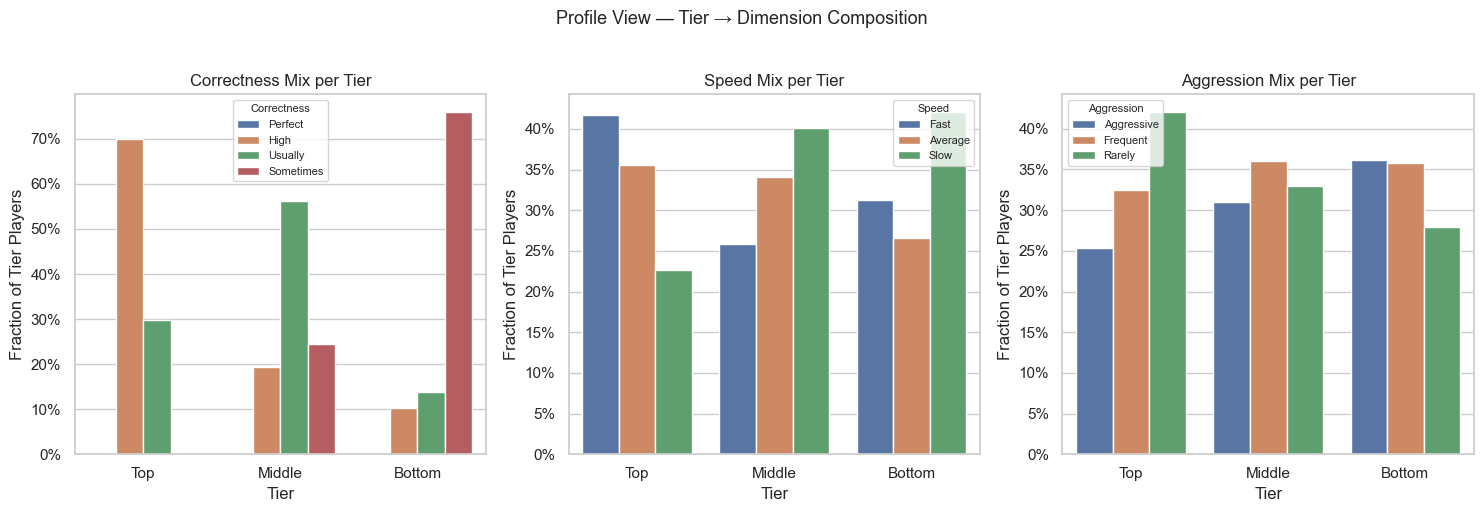

In [20]:
# Profile view — given a tier, what dimension mix does it contain?
# Each subplot is a DIMENSION; bars are tier groups.
# Read this as: "Of all Bottom-tier players, X% have 'Sometimes' correctness."

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (dim, order) in zip(axes, DIMS.items()):
    pivot = (
        proc_tier.groupby(["Tier", dim], observed=True).size().reset_index(name="count")
    )
    totals = proc_tier.groupby("Tier", observed=True).size().reset_index(name="total")
    pivot = pivot.merge(totals, on="Tier")
    pivot["fraction"] = pivot["count"] / pivot["total"]

    sns.barplot(
        data=pivot,
        x="Tier",
        y="fraction",
        hue=dim,
        hue_order=order,
        order=TERTILE_ORDER,
        ax=ax,
        errorbar=None,
    )
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.set_title(f"{dim} Mix per Tier")
    ax.set_xlabel("Tier")
    ax.set_ylabel("Fraction of Tier Players")
    ax.legend(title=dim, fontsize=8, title_fontsize=8)
    ax.tick_params(axis="x")

plt.suptitle("Profile View — Tier → Dimension Composition", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

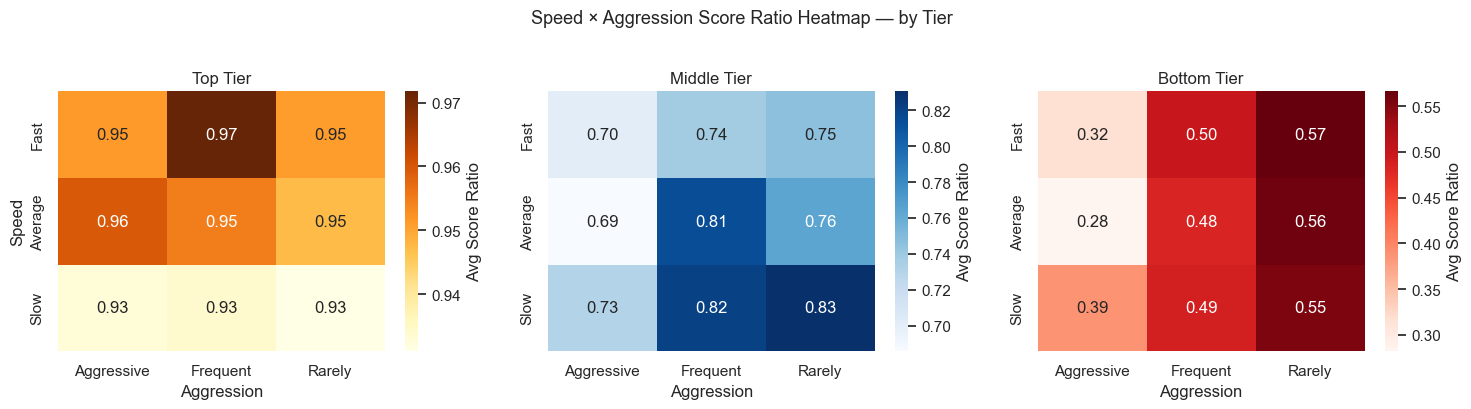

In [21]:
# Speed × Aggression Heatmap — one subplot per tier
# Each tier has its own colormap and colorbar so its internal contrast is maximised.
# Top = warm gold (YlOrBr), Middle = blue (Blues), Bottom = red (Reds).

speed_order = ["Fast", "Average", "Slow"]
agg_order = ["Aggressive", "Frequent", "Rarely"]

tier_heatmaps = {}
for tier in TERTILE_ORDER:
    sub = proc_tier[proc_tier["Tier"] == tier]
    hm = sub.pivot_table(
        index="Speed", columns="Aggression", values="Score Ratio", aggfunc="mean"
    )
    hm = hm.reindex(
        index=[s for s in speed_order if s in hm.index],
        columns=[a for a in agg_order if a in hm.columns],
    )
    tier_heatmaps[tier] = hm

TIER_CMAPS = {"Top": "YlOrBr", "Middle": "Blues", "Bottom": "Reds"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, tier in zip(axes, TERTILE_ORDER):
    hm = tier_heatmaps[tier]
    sns.heatmap(
        hm,
        annot=True,
        fmt=".2f",
        cmap=TIER_CMAPS[tier],
        ax=ax,
        cbar=True,
        cbar_kws={"label": "Avg Score Ratio"},
    )
    ax.set_title(f"{tier} Tier")
    ax.set_xlabel("Aggression")
    ax.set_ylabel("Speed" if tier == "Top" else "")

plt.suptitle(
    "Speed × Aggression Score Ratio Heatmap — by Tier",
    y=1.02,
    fontsize=13,
)
plt.tight_layout()
plt.show()

### Tier Portraits

Mirrors the "Top 100 scorers" pie chart, extended to all three tiers — lets you see which strategies clog the bottom and which ones reliably produce top-tier players.

C:\Users\Blake\AppData\Local\Temp\ipykernel_346256\2754538275.py:42: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Blake\anaconda3\envs\jbot\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


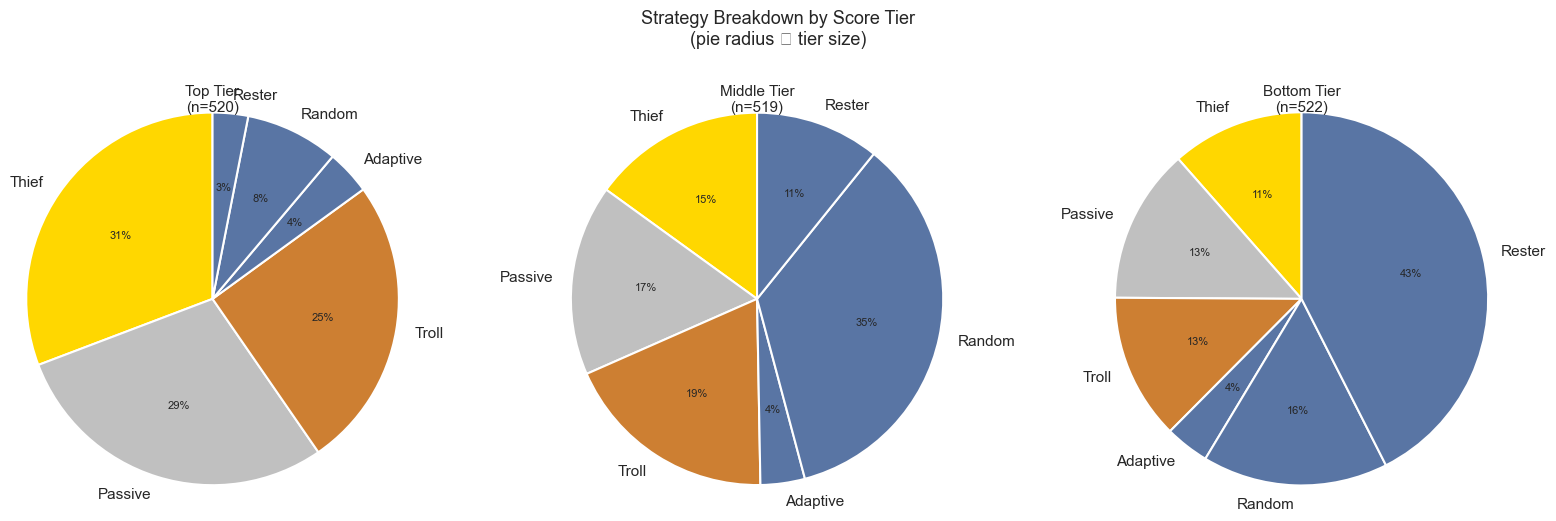

In [22]:
# Strategy makeup of each tier — three pie charts side by side
# Mirrors the "Top 100 scorers" pie but for Top / Middle / Bottom thirds.
# Circle size is proportional to total players in that tier.

pie_pal = get_rank_palette(df, "Core Strategy", "Score Ratio")

# Determine max count for radius scaling
tier_counts_total = proc_non_bench.groupby("Tier", observed=True).size()
max_count = tier_counts_total.max()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, tier in zip(axes, TERTILE_ORDER):
    tier_players = proc_non_bench[proc_non_bench["Tier"] == tier]
    counts = tier_players["Core Strategy"].value_counts()

    # Keep only strategies in ranked_strategy_order; preserve sort order
    pie_order = [s for s in ranked_strategy_order if s in counts.index]
    counts_ordered = counts.reindex(pie_order)
    colors = [pie_pal.get(s, "#888888") for s in pie_order]

    # Scale wedge radius so area is proportional to tier size
    radius = 0.8 + 0.5 * (tier_counts_total[tier] / max_count)

    wedges, texts, autotexts = ax.pie(
        counts_ordered,
        labels=pie_order,
        colors=colors,
        autopct="%1.0f%%",
        startangle=90,
        radius=radius,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    )
    for t in autotexts:
        t.set_fontsize(8)
    ax.set_title(f"{tier} Tier\n(n={len(tier_players):,})", fontsize=11)

plt.suptitle(
    "Strategy Breakdown by Score Tier\n(pie radius ∝ tier size)",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.show()

In [23]:
# Bottom 15 individual players — mirror of the Top 15 table above
pd.set_option("display.float_format", "{:.3f}".format)

display_cols = [
    "Name",
    "Score",
    "Score Ratio",
    "Streak",
    "Core Strategy",
    "Speed",
    "Correctness",
    "Aggression",
]

bottom_performers = proc_non_bench.sort_values("Score").head(15)
print("Bottom 15 Performing Players:")
print(bottom_performers[display_cols].to_string(index=False))

pd.reset_option("display.float_format")

Bottom 15 Performing Players:
           Name  Score  Score Ratio  Streak Core Strategy   Speed Correctness Aggression
 Rester_ASA_941   6332        0.080      33        Rester Average   Sometimes Aggressive
 Rester_SSA_193   6663        0.084      38        Rester    Slow   Sometimes Aggressive
 Rester_SSA_314   7776        0.098      45        Rester    Slow   Sometimes Aggressive
Rester_SSA_1193   8114        0.102      44        Rester    Slow   Sometimes Aggressive
Rester_ASA_1371   8172        0.103      44        Rester Average   Sometimes Aggressive
 Rester_ASA_669   8183        0.103      45        Rester Average   Sometimes Aggressive
Rester_ASA_1098   8271        0.104      44        Rester Average   Sometimes Aggressive
 Rester_SSA_238   8322        0.105      49        Rester    Slow   Sometimes Aggressive
Rester_SSA_1464   8376        0.106      49        Rester    Slow   Sometimes Aggressive
 Rester_ASA_100   8377        0.106      45        Rester Average   Sometimes Ag

In [24]:
# Bottom 1 per strategy — mirror of the "Top 1 per strategy" table
pd.set_option("display.float_format", "{:.3f}".format)

bottom1_rows = []
for strategy in ranked_strategy_order:
    strat_df = proc_non_bench[proc_non_bench["Core Strategy"] == strategy]
    if strat_df.empty:
        continue
    bottom1_rows.append(strat_df.nsmallest(1, "Score").iloc[0])

bottom1_df = pd.DataFrame(bottom1_rows)[display_cols].reset_index(drop=True)

print("\nBottom 1 Player per Core Strategy:\n")
print(bottom1_df.to_string(index=False))

pd.reset_option("display.float_format")


Bottom 1 Player per Core Strategy:

                 Name  Score  Score Ratio  Streak Core Strategy   Speed Correctness Aggression
        Thief_SSR_717  39650        0.500      71         Thief    Slow   Sometimes     Rarely
     Passive_SSA_1291  39865        0.503     186       Passive    Slow   Sometimes Aggressive
       Troll_SSR_1438  40255        0.508     190         Troll    Slow   Sometimes     Rarely
Adaptive_Desperate_16  34261        0.432       6      Adaptive    Slow   Sometimes Aggressive
       Random_SSA_452  29798        0.376       1        Random    Slow   Sometimes Aggressive
       Rester_ASA_941   6332        0.080      33        Rester Average   Sometimes Aggressive


## Statistical Significance

With ~300 players per strategy and 1,580 players total, almost every difference will produce a tiny p-value — **statistical significance is essentially guaranteed**. What actually matters is **effect size**: is the difference large enough to be meaningful?

This section runs three complementary tests:

1. **Kruskal-Wallis H** — global non-parametric ANOVA. Asks: "Is at least one strategy's score distribution different from the others?" Non-parametric because scores are bounded integers, not normally distributed.
2. **Pairwise Mann-Whitney U + Holm-Bonferroni correction** — "Which pairs differ, and by how much?" Shown as dual heatmaps: corrected p-value and rank-biserial effect size r (|r| < 0.1 negligible, 0.1–0.3 small, 0.3–0.5 medium, > 0.5 large).
3. **Dimension tests (Correctness, Speed, Aggression)** — Kruskal-Wallis + η² effect size, plus Spearman ρ for ordinal dimensions.

In [25]:
from scipy import stats
from itertools import combinations

# ── helpers ──────────────────────────────────────────────────────────────────


def rank_biserial_r(x, y):
    """Effect size for Mann-Whitney U: r = 1 - 2U / (n1*n2). Range [-1, 1]."""
    u_stat, _ = stats.mannwhitneyu(x, y, alternative="two-sided")
    return 1 - (2 * u_stat) / (len(x) * len(y))


def holm_bonferroni(p_values):
    """Return Holm-Bonferroni corrected p-values (list of (original, corrected) pairs)."""
    indexed = sorted(enumerate(p_values), key=lambda x: x[1])
    n = len(p_values)
    corrected = [None] * n
    prev = 0.0
    for rank, (orig_idx, p) in enumerate(indexed):
        adj = min(p * (n - rank), 1.0)
        adj = max(adj, prev)  # monotonicity
        corrected[orig_idx] = adj
        prev = adj
    return corrected


def sig_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return "ns"


def effect_label(r):
    a = abs(r)
    if a < 0.1:
        return "negligible"
    elif a < 0.3:
        return "small"
    elif a < 0.5:
        return "medium"
    return "large"


# ── global Kruskal-Wallis across all strategies ───────────────────────────────

# Build groups from df directly so this cell can run without the
# Performance Tiers section having been executed first.
_stats_nonbench = df[df["Core Strategy"] != "Benchmark"]
_stats_order = (
    _stats_nonbench.groupby("Core Strategy")["Score"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)
strat_groups = {
    s: _stats_nonbench.loc[_stats_nonbench["Core Strategy"] == s, "Score"].values
    for s in _stats_order
}

h_stat, kw_p = stats.kruskal(*strat_groups.values())
n_total = len(_stats_nonbench)
k = len(strat_groups)
# η² estimate for KW
eta_sq = (h_stat - k + 1) / (n_total - k)

print("═" * 60)
print("Kruskal-Wallis H-test  (all strategies vs. each other)")
print("═" * 60)
print(f"  H = {h_stat:.2f},  p = {kw_p:.2e},  η² = {eta_sq:.4f}")
print(f"  Interpretation: {effect_label(max(0.0, eta_sq) ** 0.5)} global effect")
print()
print("H0: all strategy score distributions are identical.")
print("A significant result only tells us *something* differs —")
print("pairwise tests below reveal *which* pairs and by how much.")

════════════════════════════════════════════════════════════
Kruskal-Wallis H-test  (all strategies vs. each other)
════════════════════════════════════════════════════════════
  H = 444.37,  p = 8.03e-94,  η² = 0.2826
  Interpretation: large global effect

H0: all strategy score distributions are identical.
A significant result only tells us *something* differs —
pairwise tests below reveal *which* pairs and by how much.


c:\Users\Blake\anaconda3\envs\jbot\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\Blake\anaconda3\envs\jbot\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\Blake\anaconda3\envs\jbot\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\Blake\anaconda3\envs\jbot\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\Blake\anaconda3\envs\jbot\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Blake\anaconda3\envs\jbot\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missi

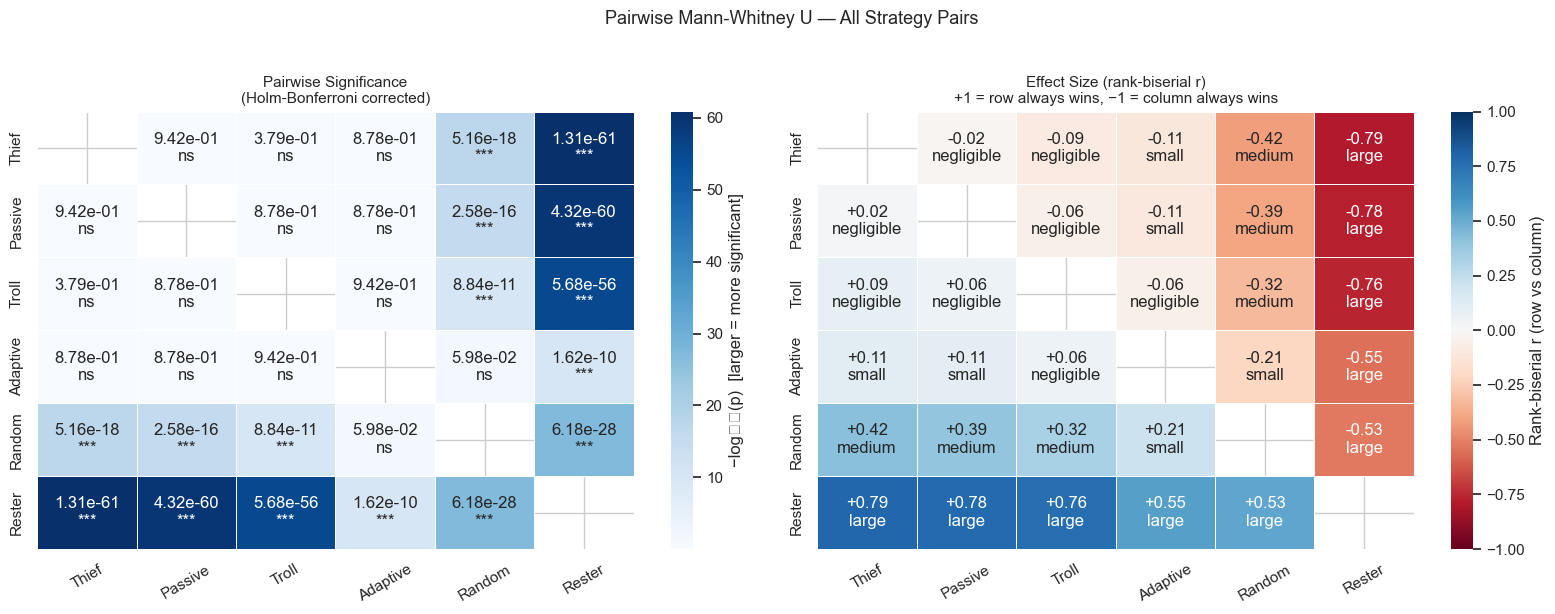

In [26]:
# Pairwise Mann-Whitney U — corrected p-values + effect sizes
# Two side-by-side annotated heatmaps: significance and rank-biserial r.

strategy_names = list(strat_groups.keys())
n_strats = len(strategy_names)
idx = {s: i for i, s in enumerate(strategy_names)}

raw_p = {}
effect_r = {}

for a, b in combinations(strategy_names, 2):
    _, p = stats.mannwhitneyu(strat_groups[a], strat_groups[b], alternative="two-sided")
    r = rank_biserial_r(strat_groups[a], strat_groups[b])
    raw_p[(a, b)] = p
    effect_r[(a, b)] = r

# Holm-Bonferroni correction
pairs = list(raw_p.keys())
corrected = holm_bonferroni([raw_p[k] for k in pairs])
corrected_p = {k: v for k, v in zip(pairs, corrected)}

# Build symmetric matrices
p_mat = pd.DataFrame(
    [[float("nan")] * n_strats for _ in range(n_strats)],
    index=strategy_names,
    columns=strategy_names,
)
r_mat = p_mat.copy()

for (a, b), cp in corrected_p.items():
    r = effect_r[(a, b)]
    p_mat.loc[a, b] = cp
    p_mat.loc[b, a] = cp
    r_mat.loc[a, b] = r
    r_mat.loc[b, a] = -r  # direction flips for b vs a

# Annotations
p_annot = p_mat.copy().astype(object)
r_annot = r_mat.copy().astype(object)
for a in strategy_names:
    for b in strategy_names:
        if a == b:
            p_annot.loc[a, b] = "—"
            r_annot.loc[a, b] = "—"
        else:
            p_v = p_mat.loc[a, b]
            r_v = r_mat.loc[a, b]
            p_annot.loc[a, b] = f"{p_v:.2e}\n{sig_stars(p_v)}"
            r_annot.loc[a, b] = f"{r_v:+.2f}\n{effect_label(r_v)}"

fig, (ax_p, ax_r) = plt.subplots(1, 2, figsize=(16, 6))

# p-value heatmap (log scale: darker = more significant)
import numpy as np

log_p_mat = p_mat.apply(
    lambda col: col.map(lambda v: -np.log10(v) if not pd.isna(v) else float("nan"))
)
mask = np.eye(n_strats, dtype=bool)

sns.heatmap(
    log_p_mat,
    annot=p_annot,
    fmt="",
    cmap="Blues",
    mask=mask,
    ax=ax_p,
    cbar_kws={"label": "−log₁₀(p)  [larger = more significant]"},
    linewidths=0.5,
)
ax_p.set_title("Pairwise Significance\n(Holm-Bonferroni corrected)", fontsize=11)
ax_p.tick_params(axis="x", rotation=30)

# Effect size heatmap (diverging: positive r = row beats column)
sns.heatmap(
    r_mat,
    annot=r_annot,
    fmt="",
    cmap="RdBu",
    center=0,
    vmin=-1,
    vmax=1,
    mask=mask,
    ax=ax_r,
    cbar_kws={"label": "Rank-biserial r (row vs column)"},
    linewidths=0.5,
)
ax_r.set_title(
    "Effect Size (rank-biserial r)\n+1 = row always wins, −1 = column always wins",
    fontsize=11,
)
ax_r.tick_params(axis="x", rotation=30)

plt.suptitle("Pairwise Mann-Whitney U — All Strategy Pairs", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [27]:
# Dimension tests — Kruskal-Wallis + η² for Correctness, Speed, Aggression.
# Also computes Spearman ρ for the two ordinal dimensions (Correctness, Speed).

# Procedural-only subset (Speed != "N/A" → has Correctness/Speed/Aggression columns).
# Computed inline so this cell runs independently of the Performance Tiers section.
_stats_proc = df[(df["Core Strategy"] != "Benchmark") & (df["Speed"] != "N/A")]

# Ordinal encodings (higher = objectively "better" at that dimension)
ORDINAL_MAPS = {
    "Correctness": {"Sometimes": 0, "Usually": 1, "High": 2, "Perfect": 3},
    "Speed": {"Slow": 0, "Average": 1, "Fast": 2},
}

dim_results = []
for dim in ["Correctness", "Speed", "Aggression"]:
    groups = [
        _stats_proc.loc[_stats_proc[dim] == v, "Score Ratio"].values
        for v in _stats_proc[dim].unique()
        if not pd.isna(v)
    ]
    h, p = stats.kruskal(*groups)
    n = _stats_proc[dim].notna().sum()
    k_dim = len(groups)
    eta2 = max((h - k_dim + 1) / (n - k_dim), 0.0)

    row = {
        "Dimension": dim,
        "H-stat": round(h, 2),
        "p-value": p,
        "η²": round(eta2, 4),
        "Effect": effect_label(eta2**0.5),
        "Spearman ρ": None,
        "ρ p-value": None,
    }

    if dim in ORDINAL_MAPS:
        encoded = _stats_proc[dim].map(ORDINAL_MAPS[dim])
        rho, rho_p = stats.spearmanr(encoded, _stats_proc["Score Ratio"])
        row["Spearman ρ"] = round(rho, 4)
        row["ρ p-value"] = rho_p

    dim_results.append(row)

dim_summary = pd.DataFrame(dim_results).set_index("Dimension")
dim_summary["p-value"] = dim_summary["p-value"].map(lambda v: f"{v:.2e}")
dim_summary["ρ p-value"] = dim_summary["ρ p-value"].map(
    lambda v: f"{v:.2e}" if v is not None else "—"
)
dim_summary["Spearman ρ"] = dim_summary["Spearman ρ"].map(
    lambda v: f"{v:+.4f}" if v is not None else "—"
)

print("═" * 70)
print("Dimension Effects on Score Ratio")
print("═" * 70)
print(dim_summary.to_string())
print()
print("η²: fraction of variance explained by that dimension (KW approximation).")
print("Spearman ρ: ordinal correlation of dimension value with Score Ratio")
print("  (only for dimensions with a meaningful ordering).")

══════════════════════════════════════════════════════════════════════
Dimension Effects on Score Ratio
══════════════════════════════════════════════════════════════════════
             H-stat    p-value      η² Effect Spearman ρ  ρ p-value
Dimension                                                          
Correctness  770.60  1.03e-166  0.4930  large    +0.6963  9.18e-227
Speed         41.36   1.04e-09  0.0253  small    +0.1465   6.04e-09
Aggression    60.66   6.74e-14  0.0376  small       +nan        nan

η²: fraction of variance explained by that dimension (KW approximation).
Spearman ρ: ordinal correlation of dimension value with Score Ratio
  (only for dimensions with a meaningful ordering).
